<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/euitae-branch/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# 4가지 파이썬 라이브러리 불러오기
import pandas as pd # pandas: 데이터 분석 활용
import numpy as np # numpy: 계산,연산
import matplotlib.pyplot as plt # matplotlib.pyplot: 2D그래프
import seaborn as sns #seaborn: 데이터 시각화 라이브러리

In [55]:
#df = sns.load_dataset('titanic') # seaborn 데이터는 정제되어 있음
#print(df.info())

In [56]:
#from sklearn.datasets import fetch_openml

# 원본에 가장 가까운 타이타닉 데이터셋 불러오기
#titanic_raw = fetch_openml('titanic', version=1, as_frame=True)
#df = titanic_raw.frame

#print(df.info())

In [57]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1. 1309개 전체 데이터를 불러옵니다.
titanic_raw = fetch_openml('titanic', version=1, as_frame=True)
df = titanic_raw.frame

# 2. 7:3 비율(test_size=0.3)로 나눕니다.
# 1309 * 0.7 ≒ 916 / 1309 * 0.3 ≒ 393
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# 3. 개수 확인
print(f"학습용(df_train): {len(df_train)}개")
print(f"테스트용(df_test): {len(df_test)}개")

# 인덱스가 뒤죽박죽인 게 보기 싫다면 깔끔하게 정리!
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head(5)

학습용(df_train): 916개
테스트용(df_test): 393개


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,3,0,"Smiljanic, Mr. Mile",male,NaN,0,0,315037,8.6625,NaN,S,NaN,NaN,NaN
1,3,0,"Bostandyeff, Mr. Guentcho",male,26.0,0,0,349224,7.8958,NaN,S,NaN,NaN,"Bulgaria Chicago, IL"
2,2,1,"Phillips, Miss. Kate Florence ('Mrs Kate Louis...",female,19.0,0,0,250655,26.0000,NaN,S,11,NaN,"Worcester, England"
3,3,0,"Sage, Miss. Dorothy Edith 'Dolly'",female,NaN,8,2,CA. 2343,69.5500,NaN,S,NaN,NaN,NaN
4,3,0,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,NaN,NaN,NaN


In [58]:
print(df_train.info())
print("---------------------")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     916 non-null    int64   
 1   survived   916 non-null    category
 2   name       916 non-null    object  
 3   sex        916 non-null    category
 4   age        729 non-null    float64 
 5   sibsp      916 non-null    int64   
 6   parch      916 non-null    int64   
 7   ticket     916 non-null    object  
 8   fare       915 non-null    float64 
 9   cabin      204 non-null    object  
 10  embarked   915 non-null    category
 11  boat       327 non-null    object  
 12  body       85 non-null     float64 
 13  home.dest  510 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 81.9+ KB
None
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 14 columns):
 #   Column     Non-Null Count 

In [59]:
# 불필요한 피처 제거
# 데이터셋에서 name, ticket, body, cabin, home.dest 피처 제거
columns_to_drop = ['name', 'ticket', 'body', 'cabin', 'home.dest']

# df_train에서 존재하는 열만 제거
existing_columns_train = [col for col in columns_to_drop if col in df_train.columns]
if existing_columns_train:
    df_train = df_train.drop(existing_columns_train, axis=1)

# df_test에서 존재하는 열만 제거
existing_columns_test = [col for col in columns_to_drop if col in df_test.columns]
if existing_columns_test:
    df_test = df_test.drop(existing_columns_test, axis=1)

In [60]:
print(df_train.info())
print("---------------------")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    916 non-null    int64   
 1   survived  916 non-null    category
 2   sex       916 non-null    category
 3   age       729 non-null    float64 
 4   sibsp     916 non-null    int64   
 5   parch     916 non-null    int64   
 6   fare      915 non-null    float64 
 7   embarked  915 non-null    category
 8   boat      327 non-null    object  
dtypes: category(3), float64(2), int64(3), object(1)
memory usage: 46.1+ KB
None
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    393 non-null    int64   
 1   survived  393 non-null    category
 2   sex       393 non-null    category
 3   age       317 non-null    float64 
 4   sibs

survived
0    585
1    331
Name: count, dtype: int64


<Axes: xlabel='survived'>

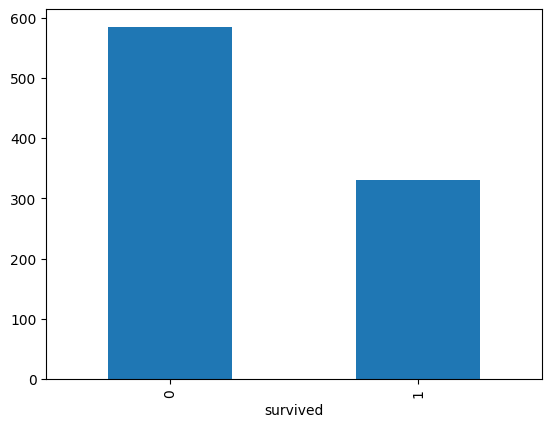

In [61]:
# 탐색적 데이터 분석
print(df_train['survived'].value_counts()) # 고유 값 세기
df_train['survived'].value_counts().plot.bar() # 막대 그래프

pclass
3    507
1    227
2    182
Name: count, dtype: int64


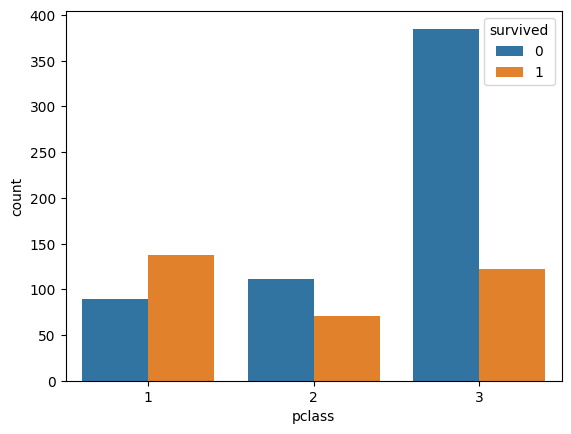

In [62]:
# 생존 여부로 그룹 나누기
print(df_train['pclass'].value_counts())
ax = sns.countplot(x='pclass', hue='survived', data=df_train)
#

In [63]:
from scipy import stats
# 두 집단 피처 비교,탐색 자동화 하는 함수 정의
def valid_features(df, col_name, distribution_check=True):
    # 두 집단 생존 여부 분포 그래프 출력
    g = sns.FacetGrid(df, col='survived')
    g.map(plt.hist, col_name, bins= 30)

    # 두 집단 표준편차 출력
    titanic_survived_data = df[df['survived']==1]
    titanic_not_survived_data = df[df['survived']==0]

    # survived group
    titanic_survived_static = np.array(titanic_survived_data[col_name])
    print("Survived group std is", '%.2f' % np.std(titanic_survived_static))

    # not survived group
    titanic_not_survived_static = np.array(titanic_not_survived_data[col_name])
    print("Not survived group std is", '%.2f' % np.std(titanic_not_survived_static))

    # T-test로 두 집단 평균 차이 검정
    tTestResult = stats.ttest_ind(titanic_survived_data[col_name], titanic_not_survived_data[col_name])
    tTestResultDiffvar = stats.ttest_ind(titanic_survived_data[col_name], titanic_not_survived_data[col_name], equal_var=False)
    print("The t-statistic and p-value assuming equal variances is %.3f and %.3f" % tTestResult)
    print("The t-statistic and p-value not assuming equal variances is %.3f and %.3f" % tTestResultDiffvar)

    if distribution_check:
      # shapiro wilk 검정: 두 집단이 나눠진게 아닌 전체의 정규성 검정
      print("The w-statistic and p-value in suvived % .3f and %.3f" % stats.shapiro(titanic_survived_data[col_name]))
      print("The w-statistic and p-value in not survived % .3f and %.3f" % stats.shapiro(titanic_not_survived_data[col_name]))

Survived group std is nan
Not survived group std is nan
The t-statistic and p-value assuming equal variances is nan and nan
The t-statistic and p-value not assuming equal variances is nan and nan
The w-statistic and p-value in suvived  nan and nan
The w-statistic and p-value in not survived  nan and nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/tmp/ipykernel_2902/255736289.py:28: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("The w-statistic and p-value in suvived % .3f and

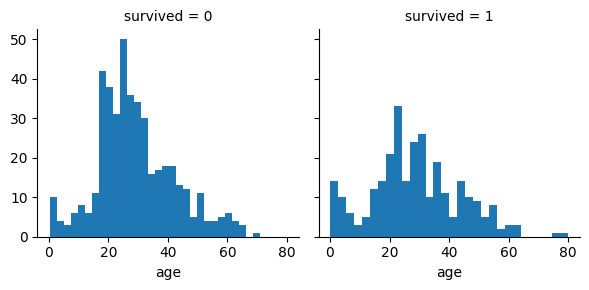

In [64]:
# 앞서 정의한 valid_features 함수 실행. age 피처 탐색합니다.
valid_features(df_train[df_train['age'] > 0], 'age', distribution_check=True)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Survived group std is nan
Not survived group std is nan
The t-statistic and p-value assuming equal variances is nan and nan
The t-statistic and p-value not assuming equal variances is nan and nan


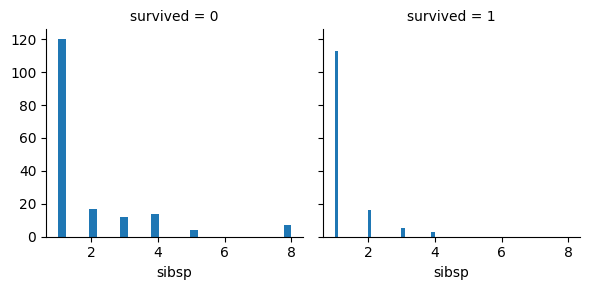

In [65]:
# valid_features 함수 실행, sibsp 피처 탐색
valid_features(df_train[df_train['sibsp'] > 0 ], 'sibsp', distribution_check=False)

In [66]:
# 생존자 분류 모델 만들기

# age의 결측값을 평균값으로 대체
# 연속형 데이터라서 평균값
replace_mean_age = df_train['age'].mean()
df_train['age'] = df_train['age'].fillna(replace_mean_age)
df_test['age'] = df_test['age'].fillna(replace_mean_age)

# fare의 결측값을 평균값으로 대체
# 연속형 데이터라서 평균값
replace_mean_fare = df_train['fare'].mean()
df_train['fare'] = df_train['fare'].fillna(replace_mean_fare)
df_test['fare'] = df_test['fare'].fillna(replace_mean_fare)

# embark: 2개의 결측값을 최빈값으로 대체
# 범주형 데이터라서 최빈
embarked_mode = df_train['embarked'].value_counts().index[0]
df_train['embarked'] = df_train['embarked'].fillna(embarked_mode)
df_test['embarked'] = df_test['embarked'].fillna(embarked_mode)

# one - hot encoding을 위한 통합 데이터 프레임(whole_df)을 생성
whole_df = pd.concat([df_train, df_test], ignore_index=True)
train_idx_num = len(df_train)

# pandas 패키지를 이용한 one-hot 인코딩 수행
whole_df_encoded = pd.get_dummies(whole_df)
df_train_encoded = whole_df_encoded.iloc[:train_idx_num, :]
df_test_encoded = whole_df_encoded.iloc[train_idx_num:, :]

df_train.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,boat
0,3,0,male,29.102309,0,0,8.6625,S,NaN
1,3,0,male,26.000000,0,0,7.8958,S,NaN
2,2,1,female,19.000000,0,0,26.0000,S,11
3,3,0,female,29.102309,8,2,69.5500,S,NaN
4,3,0,female,28.000000,0,0,7.7750,S,NaN


In [67]:
# 데이터를 학습 데이터셋 테스트 데이터 셋 분리

# Use the one-hot encoded dataframes for features
# and the original 'survived' column (converted to int) for labels.

# Extract target variable 'survived' from original dataframes and convert to int
y_train = df_train['survived'].astype(int)
y_test = df_test['survived'].astype(int)

# Prepare feature sets from the one-hot encoded dataframes.
# Drop columns related to 'survived' from the encoded dataframes as they are now our target.
columns_to_drop_from_encoded = [col for col in df_train_encoded.columns if 'survived' in col]
x_train = df_train_encoded.drop(columns=columns_to_drop_from_encoded, axis=1)

columns_to_drop_from_encoded_test = [col for col in df_test_encoded.columns if 'survived' in col]
x_test = df_test_encoded.drop(columns=columns_to_drop_from_encoded_test, axis=1)

# Ensure x_train and x_test have identical columns, which is important for model consistency.
# This step handles potential discrepancies in columns generated by get_dummies if
# one-hot encoded categories are not present in both train and test sets.
common_cols = list(set(x_train.columns) & set(x_test.columns))
x_train = x_train[common_cols]
x_test = x_test[common_cols]


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 로지스틱 회귀 모델 학습
lr = LogisticRegression()
lr.fit(x_train, y_train)

# 모델의 테스트 데이터셋에 대한 예측 결과 반환
y_pred = lr.predict(x_test)
y_pred_probability = lr.predict_proba(x_test)[:,1]

# 모델의 성능 평가

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
